# Meta Learners - Infant Development and Specialist Visits

In this notebook we use the meta-learer framework to estimate conditional average treatment effects (CATEs). The meta-learned frameworks leverages flexible machine learning models for the estimation of treatment effects in high dimensional settings where the functional form is unknown. We use the Infant Health and Development Program (IHDP) dataset. IHDP was originally a randomised controlled experiment studying the effectiveness of home visits on the cognitive development of premature, low-birth-weight infants. Hill (2011) made two modifications to the dataset making it the standard testbed for the estimation of HTEs: a nonrandom subset of the treated group was removed, so treatment assignment is confounded the way observational data is, and the outcomes are simulated from the real covariates – so both potential outcomes, and therefore every unit’s true effect, are known. 

In this notebook I first introduce the idea of heterogenous treatment effects and link them to the dataset to make concrete what we are trying to achieve. We then load the data...

# Heterogenous Treatment Effects (HTEs)

A lot of times just knowing the average treatment effect of a treatment is not good enough, especially when there is a fixed cost to treating and our units are heterogenous (e.g. are humans). For example, a marketing department may find that when offering discounts some of the customers would have bought the product regardless of whether they received a discount (this is called leaving money on the table). The customers in this example displayed heterogenous treatment effects, they responded differently to the treatment. For some, the discount increased the probability of purchase and for others the probability was not changed.

$$
CATE = E[Y_{1} - Y_{0} | X]
$$

The formula above says the CATE is the expected difference between the outcome where treatment was received and not received given some value of the covariates $X$. We can think of this difference as a function of $X$, as we change the value of the covariates then the average difference in potential outcomes changes. That is the effect of the treatment depends upon the makeup of the unit being treated. 

However, as always in causal inference we have do not observe both potential outcomes. To get a sense of how we can get to an estimate of the CATE consider the following model

$$
y_{i} = \beta_{0} + \beta_{1}t_{i} + \bold{\beta_{2}X_{i}} + \beta_{3}t*\bold{X_{i}}
$$

If we differentiate with respect the treatment this tells us how the outcome changes with respect to the treatment and as we have the interaction term this derivative is dependent on the values of covariates and therefore we have some estimate of the CATE

$$
\frac{\partial{y}}{\partial{t}} = \beta_{1} + \bold{\beta_{3}}\bold{X_{i}}
$$

However, there can be many covariates in the vector $\bold{X_{i}}$ and a linear model or more generally a data model that we specify is unlikely to capture the true interaction between the covariates and the treatment. In the IHDP example we have 25 covariates which cover the child's measurement and the social/behavioural indicators about the mother, the treatment is binary and captures whether a child was subject to high-quality and intensive home visits and the outcome is the child's score on a cognitive test at age 3. In the context of this notebook we are interested in whether we can idenitfy groups of the covariates with different ATEs.

In [28]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from get_data import fetch_ihdp_data
from causalml.propensity import ElasticNetPropensityModel
import matplotlib.pyplot as plt
from causalml.inference import meta
from xgboost import XGBRegressor

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import warnings 
warnings.filterwarnings("ignore")

## Load Data

In [9]:
RS = 42
np.random.seed(RS)

train = fetch_ihdp_data(replication=0, split="train")
test = fetch_ihdp_data(replication=0, split="test")
X_tr = pd.DataFrame(train.data, columns=train.feature_names)
w_tr, y_tr, tau_tr = train.treatment, train.target, train.tau
X_te = pd.DataFrame(test.data, columns=test.feature_names)
w_te, y_te, tau_te = test.treatment, test.target, test.tau

print(X_tr.shape, w_tr.sum(), X_te.shape, w_te.sum())
print("true ATE: %.3f | sd of tau: %.3f" % (tau_tr.mean(), tau_tr.std()))

(672, 25) 123 (75, 25) 16
true ATE: 4.012 | sd of tau: 0.866


## Indentification and Overlap

Before any estimation we should consider if we can identify any treatment effect from the data. We assume that treatment assignment is unconfounded given the covariates. This means that we can control for every variables which causes both treatment assignment and outcome. Every estimator we introduce below rests on this assumption. In this dataset this assumption is true by construction because the outcome was simulated from the covariates. In practice this is an untestable assumption.

The other requirement for identification is overlap. The treated group and the control group must have significant overlap across the covariates. When we translate this into a propensity score it means that every unit/group must have some positive probability of recieving treatment if this is true then both potential outcomes are represented in every point where we estimate the CATE meaning the model does not need to extrapolate. Unlike unconfoundedness assumption above we can check overlap assumption holds. The two distributions have significant overlap therefore estimation is possible. However, we do have poor overlap for some of treated group with a high probability of treatment and a spike in the control group with near zero propensity scores. 

In [27]:
prop_model = ElasticNetPropensityModel(Cs=np.logspace(0, 3, 8), random_state=RS)
prop_model.fit(X_tr, w_tr)

p_tr, p_te = prop_model.predict(X_tr), prop_model.predict(X_te)

print(np.sum(p_tr[w_tr==0] == 0))

0


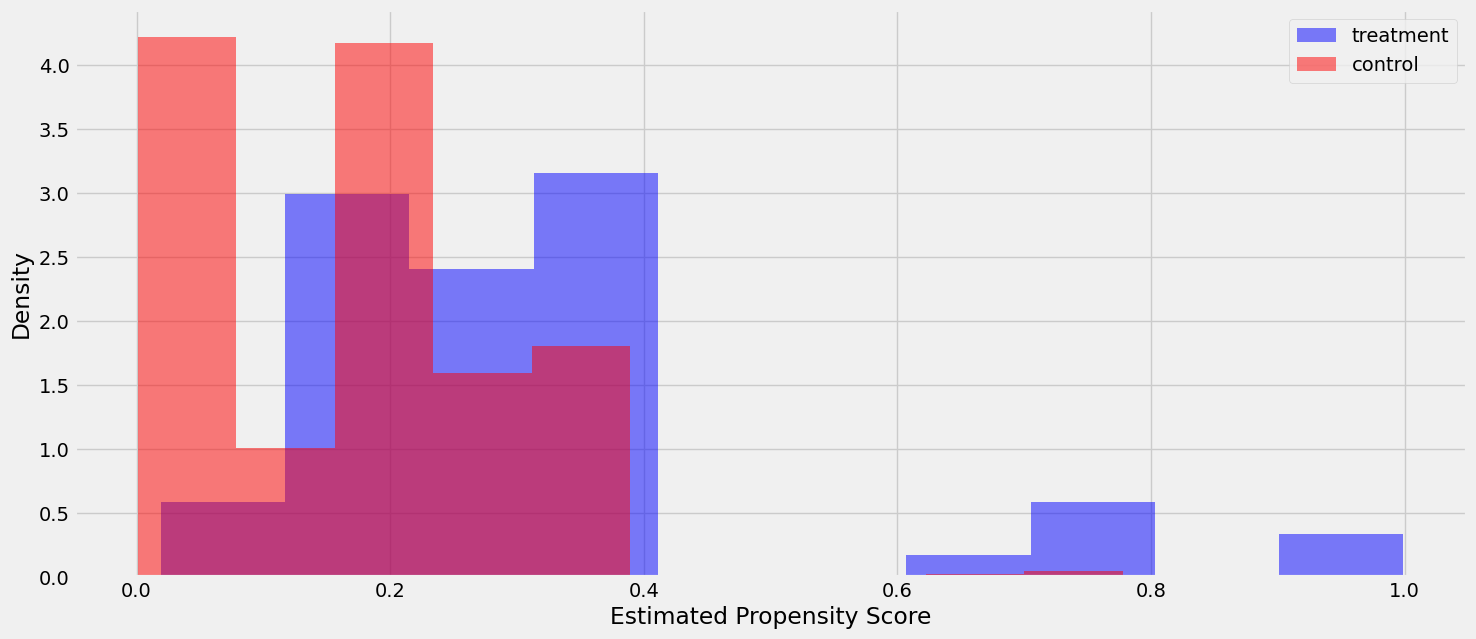

In [26]:
fig, ax = plt.subplots(1,1,figsize=(16,7))

ax.hist(p_tr[w_tr == 1], color='blue', alpha=0.5, label='treatment', density=True)
ax.hist(p_tr[w_tr == 0], color='red', alpha=0.5, label='control', density=True)
ax.set_xlabel('Estimated Propensity Score')
ax.set_ylabel('Density')
ax.legend()

## Linear Regression

How we can use linear regression to estimate HTE



In [ ]:
# LR estimate

# Meta Learners

* S-learner

* T-learner

* X-learner

In [ ]:
# S-learner
slearner = meta.BaseSLearner(XGBRegressor(random_state=RS))
slearner.fit(X=X_tr, treatment=w_tr, y=y_tr)
slearner.estimate_ate(X=X_tr, treatment=w_tr, y=y_tr)

array([3.88314187])

In [ ]:
# T-learner
tlearner = meta.BaseTLearner(XGBRegressor(random_state=RS), XGBRegressor(random_state=RS))
tlearner.fit(X=X_tr, treatment=w_tr, y=y_tr, p=p_tr)
tlearner.estimate_ate(X=X_tr, treatment=w_tr, y=y_tr, p=p_tr)


(array([3.957823]), array([3.84010132]), array([4.07554467]))

In [34]:
# X-learner
xlearner = meta.BaseXLearner(learner=XGBRegressor(random_state=RS))
xlearner.fit(X=X_tr, treatment=w_tr, y=y_tr, p=p_tr)
xlearner.estimate_ate(X=X_tr, treatment=w_tr, y=y_tr, p=p_tr)


(array([4.15609956]), array([4.07257244]), array([4.23962668]))

# Causal Model Evalutation

Introduce the two sections. 1 is to evaluate estimators as we have the actual data in this scenrario inlcude recovery of ATE and the PEHE

Facure, is the more practical methodology. In the real world we don't the actual data its not observable so what makes a good causal model? One that can seperate groups by sensitivity to treatment.

* Sensitivity analysis

* Cumulative sensitivity curve + interpretation

* Cumulative gain curve + interpretation

# Bibliography

Facure Brave and True

https://causalml.readthedocs.io/en/latest/tutorial.html

Meta Learners paper